# Day 1 · Notebook 01 — Tensors & Autograd

**Day 1:** PyTorch Fundamentals

By the end of this notebook you will be able to:

1. Create tensors and reason about their **shape**, **dtype** and **device**.
2. Index, reshape and combine tensors, and predict the result of **broadcasting** and **matrix multiplication**.
3. Explain what **autograd** does: how PyTorch records a *computational graph* and uses it to compute gradients.
4. Use `requires_grad`, `.backward()`, `.grad`, `torch.no_grad()` and `.detach()` correctly.
5. Fit a straight line **from scratch** with manual gradient descent — and then with `nn.Linear` + `torch.optim` to see what the library does for you.

## 0. Setup

We import PyTorch and fix the random seed so everybody in the room gets the **same numbers**. Reproducibility matters: when you debug or compare experiments, you want differences to come from your changes, not from random chance.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

---
# Part 1 — Tensors

A **tensor** is PyTorch's n-dimensional array. It is very similar to a NumPy `ndarray`, with two super-powers:

1. it can live on a **GPU** (or other accelerator) for fast parallel maths, and
2. it can **track the operations** applied to it so that gradients can be computed automatically (autograd).

| Rank | Name | Example in ML | Typical shape |
|---|---|---|---|
| 0 | scalar | a loss value | `()` |
| 1 | vector | a bias vector | `(10,)` |
| 2 | matrix | a batch of tabular rows | `(batch, features)` |
| 3 | 3-D tensor | a batch of sequences | `(batch, seq_len, features)` |
| 4 | 4-D tensor | a batch of images | `(batch, channels, height, width)` ← PyTorch uses **NCHW** |

## 1.1 Creating tensors

In [ ]:
a = torch.tensor([1, 2, 3])                 # from a Python list
b = torch.tensor([[1.0, 2.0], [3.0, 4.0]])  # 2-D, floats
z = torch.zeros(2, 3)                       # all zeros
o = torch.ones(2, 3)                        # all ones
r = torch.arange(0, 10, 2)                  # like range(): 0,2,4,6,8
l = torch.linspace(0, 1, 5)                 # 5 evenly spaced points in [0, 1]
u = torch.rand(2, 2)                        # uniform  U[0, 1)
n = torch.randn(2, 2)                       # standard normal N(0, 1)

for name, t in [("a", a), ("b", b), ("z", z), ("o", o), ("r", r), ("l", l), ("u", u), ("n", n)]:
    print(f"{name}: shape={tuple(t.shape)}, dtype={t.dtype}\n{t}\n")

### NumPy ↔ PyTorch

`torch.from_numpy()` and `.numpy()` **share memory** on the CPU — no copy is made. Changing one changes the other. This is fast, but it can surprise you. `torch.tensor(np_array)` always makes a **copy**.

In [ ]:
arr = np.array([1.0, 2.0, 3.0])
shared = torch.from_numpy(arr)   # shares memory
copied = torch.tensor(arr)       # independent copy

arr[0] = 100.0
print("numpy array :", arr)
print("from_numpy  :", shared, " <- changed too!")
print("torch.tensor:", copied, " <- unchanged")

## 1.2 The three attributes you must always know: `shape`, `dtype`, `device`

Most PyTorch bugs are one of:
* **shape mismatch** (e.g. `(64, 10)` vs `(64,)`),
* **dtype mismatch** (e.g. `float64` input into a `float32` model, or `float` labels for `CrossEntropyLoss` which expects `long`),
* **device mismatch** (model on GPU, data on CPU).

When something breaks, **print these three first**.

In [ ]:
x = torch.randn(4, 3, 28, 28)   # a fake batch: 4 grey-ish images with 3 channels
print("shape :", x.shape)       # torch.Size is a tuple subclass
print("ndim  :", x.ndim)
print("numel :", x.numel())     # total number of elements = 4*3*28*28
print("dtype :", x.dtype)
print("device:", x.device)

## 1.3 Reshaping

| Operation | What it does |
|---|---|
| `view(shape)` | new *view* on the same memory (requires contiguous memory) |
| `reshape(shape)` | like `view` but copies if it has to — the safe default |
| `unsqueeze(d)` / `squeeze(d)` | add / remove a dimension of size 1 |
| `permute(...)` | reorder dimensions (e.g. NCHW → NHWC for plotting) |
| `flatten(start_dim)` | collapse dimensions — used to go from conv feature maps to a linear layer |

`-1` in a shape means *"infer this dimension"*.

In [ ]:
t = torch.arange(12)
print("original        :", t.shape)
print("view(3, 4)      :", t.view(3, 4).shape, " (same result as reshape here)")
print("reshape(3, 4)   :", t.reshape(3, 4).shape)
print("reshape(2, -1)  :", t.reshape(2, -1).shape, " (-1 inferred as 6)")

img = torch.rand(3, 32, 32)            # C, H, W
batch = img.unsqueeze(0)               # add batch dim -> 1, C, H, W
print("unsqueeze(0)    :", batch.shape)
print("squeeze(0)      :", batch.squeeze(0).shape)
print("permute(1, 2, 0):", img.permute(1, 2, 0).shape, " (H, W, C for matplotlib)")

images = torch.rand(64, 1, 28, 28)
print("flatten(1)      :", images.flatten(start_dim=1).shape, " (keep batch dim, flatten the rest)")

### `view` vs `reshape` — what's the difference?

Think of a tensor as **one long row of numbers in memory**, plus a "label" that says how to read it (the shape).

```
memory:            [ 0  1  2  3  4  5 ]

x  (2, 3)          0  1  2      <- read left to right: IN ORDER
                   3  4  5

x.T (3, 2)         0  3         <- must jump around in memory: JUMBLED
                   1  4            (PyTorch says "not contiguous")
                   2  5
```

| | in-order tensor (`x`) | jumbled tensor (`x.T`, after `permute`) |
|---|---|---|
| `view` | ✅ works, **shares** memory | ❌ **error** |
| `reshape` | ✅ works, **shares** memory | ✅ works, makes a **copy** |

* `view` only changes the label — never copies. Fast, but it refuses to work on a jumbled tensor.
* `reshape` = "use `view` if you can, otherwise copy". That's why `reshape` is the safe default.
* Sharing memory matters: if two tensors share memory, **changing one changes the other**.

In [ ]:
def what_happens(op, src):
    try:
        out = op()
    except RuntimeError:
        return "ERROR"
    if out.data_ptr() == src.data_ptr():   # same start address in memory?
        return "works, SAME memory"
    return "works, makes a COPY"

x  = torch.arange(6).view(2, 3)   # numbers stored in order
xt = x.T                          # same numbers, read in a jumbled order

# Side-by-side: view vs reshape
print(f"{'':18s}{'.view(6)':24s}{'.reshape(6)'}")
print("-" * 60)
for label, src in [("x   (in order)", x), ("x.T (jumbled)", xt)]:
    print(f"{label:18s}{what_happens(lambda: src.view(6), src):24s}{what_happens(lambda: src.reshape(6), src)}")

# Proof: change x and see who follows
v  = x.view(6)
r  = x.reshape(6)
rt = xt.reshape(6)
x[0, 0] = 100
print("\nNow we change x[0, 0] to 100 ...")
print("x.view(6)      :", v,  " <- changed (shares memory)")
print("x.reshape(6)   :", r,  " <- changed (no copy was needed)")
print("x.T.reshape(6) :", rt, " <- NOT changed (it is a copy)")

## 1.4 Data types (`dtype`)

* Python floats become `torch.float32` by default — the standard for deep learning.
* Python ints become `torch.int64` (a.k.a. `torch.long`) — the standard for **class labels**.
* Lower precision (`float16`, `bfloat16`, `int8`) saves memory and time. We will use this on **Day 2 (quantization)**!

In [ ]:
print(torch.tensor([1, 2]).dtype)          # int64
print(torch.tensor([1.0, 2.0]).dtype)      # float32
print(torch.tensor(np.array([1.0])).dtype) # float64! NumPy's default -> convert with .float()

x = torch.tensor([1, 2, 3])
print("int -> float :", x.float(), x.float().dtype)
print("float -> long:", torch.tensor([1.7, 2.2]).long())   # truncates!

# Precision matters: float16 has only ~3 decimal digits of precision
print("float32:", torch.tensor(1/3, dtype=torch.float32).item())
print("float16:", torch.tensor(1/3, dtype=torch.float16).item())

## 1.5 Indexing, slicing and boolean masks

Indexing works like NumPy. Boolean masks are especially handy, e.g. to find the misclassified examples later today.

In [ ]:
m = torch.arange(1, 13).reshape(3, 4)
print(m)
print("row 0          :", m[0])
print("column 1       :", m[:, 1])
print("last row       :", m[-1])
print("sub-matrix     :\n", m[:2, 1:3])

mask = m % 2 == 0
print("mask           :\n", mask)
print("even numbers   :", m[mask])

preds  = torch.tensor([0, 2, 1, 1, 3])
labels = torch.tensor([0, 1, 1, 2, 3])
print("wrong indices  :", torch.nonzero(preds != labels).flatten())
print("accuracy       :", (preds == labels).float().mean().item())

## 1.6 Element-wise operations and reductions

Arithmetic operators (`+ - * / **`) act **element-wise**. Reductions (`sum`, `mean`, `max`, `argmax`) collapse a dimension. The `dim` argument says **which dimension disappears**.

```
        dim=1 →
dim=0  [[1, 2, 3],        sum(dim=0) -> [5, 7, 9]      (collapse rows)
  ↓     [4, 5, 6]]        sum(dim=1) -> [6, 15]        (collapse columns)
```

In [ ]:
x = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])
print("x * 2           :\n", x * 2)
print("x * x           :\n", x * x)
print("sum()           :", x.sum())
print("sum(dim=0)      :", x.sum(dim=0))
print("sum(dim=1)      :", x.sum(dim=1))

logits = torch.tensor([[2.0, 0.5, 0.1],
                       [0.2, 0.1, 3.0]])
print("argmax(dim=1)   :", logits.argmax(dim=1), " <- predicted class per row")

## 1.7 Broadcasting

Broadcasting lets PyTorch combine tensors of **different shapes** without copying data. Rules (compare shapes **from the right**):

1. If the two dimensions are equal → fine.
2. If one of them is 1 → it is *stretched* to match the other.
3. If a tensor has fewer dims, it is padded with 1s **on the left**.
4. Otherwise → **error**.

```
   (3, 1)          (64, 784)          (64, 10)
 + (1, 4)        - (   784)  mean   + (    10)  bias
 = (3, 4)        = (64, 784)        = (64, 10)
```

In [ ]:
col = torch.tensor([[1.], [2.], [3.]])      # shape (3, 1)
row = torch.tensor([[10., 20., 30., 40.]])  # shape (1, 4)
print("col + row -> shape", (col + row).shape)
print(col + row)

# Real use case: standardise each feature (column) of a data matrix
X = torch.randn(100, 5) * 3 + 7
X_std = (X - X.mean(dim=0)) / X.std(dim=0)   # (100,5) - (5,) -> (100,5)
print("\nper-feature mean after standardising:", X_std.mean(dim=0).round(decimals=4))
print("per-feature std  after standardising:", X_std.std(dim=0).round(decimals=4))

## 1.8 Matrix multiplication

`A @ B` (or `torch.matmul`) needs the **inner dimensions to match**: `(n, k) @ (k, m) → (n, m)`.

A linear layer is just `y = x @ W.T + b`:

```
   x          W.T          b          y
(batch, in) @ (in, out)  + (out,)  = (batch, out)
```

With 3-D tensors, `@` performs a **batched** matmul over the leading dimension.

In [ ]:
x = torch.randn(64, 784)        # batch of 64 flattened 28x28 images
W = torch.randn(10, 784)        # 10 output units
b = torch.randn(10)

y = x @ W.T + b
print("linear layer output:", y.shape)

A_ = torch.randn(8, 3, 4)
B_ = torch.randn(8, 4, 5)
print("batched matmul      :", (A_ @ B_).shape)

try:
    x @ W                       # (64,784) @ (10,784) -> inner dims 784 vs 10 do not match
except RuntimeError as e:
    print("\nExpected error ->", e)

Note: `*` is element-wise, `@` is matrix multiplication. Mixing them up is a very common mistake.

## 1.9 Devices: CPU, CUDA, MPS

All tensors taking part in one operation must be on the **same device**. The idiom we will use all week:

```python
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)          # moves parameters (in-place for modules)
x, y = x.to(device), y.to(device) # returns NEW tensors -> you must re-assign!
```

(On Apple Silicon you could use `"mps"`.) On this CPU-only course machine `device` will be `"cpu"`, but the code is identical on a GPU.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

t = torch.randn(3, 3)
# print(t.dtype)
t_dev = t.to(device)             # .to() returns a new tensor (or the same one if already there)
print("t on", t.device, "| t_dev on", t_dev.device)

# Getting a Python number / NumPy array back (always via CPU):
print("scalar via .item()     :", t_dev.sum().item())
print("numpy via .cpu().numpy():", t_dev.cpu().numpy().shape)

---
# Part 2 — Autograd: automatic differentiation

Training a neural network = **minimising a loss** by nudging every parameter in the direction that lowers the loss. That direction is given by the **gradient** $\frac{\partial L}{\partial \theta}$.

When a tensor has `requires_grad=True`, PyTorch records every operation on it in a **computational graph** (a DAG). Calling `.backward()` on a scalar walks this graph **backwards**, applying the chain rule, and stores the result in each leaf tensor's `.grad`.

```
 forward  ─────────────────────────────►
   x ──┐
       ├─(pow 2)──► x² ──┐
       │                 ├─(add)──► y
       └─(mul 3)──► 3x ──┘
 ◄───────────────────────────── backward
   dy/dx = 2x + 3
```

## 2.1 A first gradient

Let $y = x^2 + 3x$. Analytically $\frac{dy}{dx} = 2x + 3$, so at $x = 2$ the gradient is $7$.

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x

print("y          :", y)
print("y.grad_fn  :", y.grad_fn, " <- the op that created y")

y.backward()                 # compute dy/dx
print("dy/dx at 2 :", x.grad, " (expected 2*2 + 3 = 7)")

## 2.2 Gradients accumulate

`.backward()` **adds** to `.grad`, it does not overwrite it. This is deliberate (useful for gradient accumulation across mini-batches), but it means you **must zero the gradients** at every training step — that's why every training loop contains `optimizer.zero_grad()`.

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
for i in range(3):
    y = x**2 + 3*x
    y.backward()
    print(f"after backward #{i+1}: x.grad = {x.grad.item()}")   # 7, 14, 21 ...

x.grad.zero_()      # reset (the optimizer does this for all params with zero_grad())
print("after zero_():", x.grad.item())

## 2.4 Turning autograd off: `torch.no_grad()` and `.detach()`

Recording the graph costs memory and time. We **don't** want it when:

* **evaluating / predicting** — wrap in `with torch.no_grad():` (or the even faster `torch.inference_mode()`),
* **updating parameters manually** — the update itself must not become part of the graph,
* **logging / plotting** a tensor — use `.detach()` (returns a tensor that shares data but has no history), often followed by `.cpu().numpy()`.

And one more tool to keep gradients clean: **`zero_grad()`**. Because `.backward()` *adds* to `.grad` (see 2.3), we wipe the old gradients before every new backward — by hand with `w.grad.zero_()`, or for all parameters at once with `optimizer.zero_grad()`.

In [ ]:
w = torch.randn(3, requires_grad=True)

y = w * 2
print("normal     : requires_grad =", y.requires_grad)

with torch.no_grad():
    y2 = w * 2
print("no_grad    : requires_grad =", y2.requires_grad)

y3 = (w * 2).detach()
print("detach     : requires_grad =", y3.requires_grad)

---
# Part 3 — Gradient descent from scratch: fitting $y = 3x + 2$

We generate noisy data from a known line and ask: *can we recover $w = 3$ and $b = 2$ using only autograd?*

**Gradient descent** repeats:

1. **Forward**: $\hat y = w x + b$
2. **Loss**: mean squared error $L = \frac{1}{N}\sum (\hat y - y)^2$
3. **Backward**: autograd computes $\partial L / \partial w$ and $\partial L / \partial b$
4. **Update**: $\theta \leftarrow \theta - \eta \cdot \partial L / \partial \theta$ ( $\eta$ = learning rate )
5. **Zero** the gradients

These five steps are *exactly* what we will do on images this afternoon — only the model gets bigger.

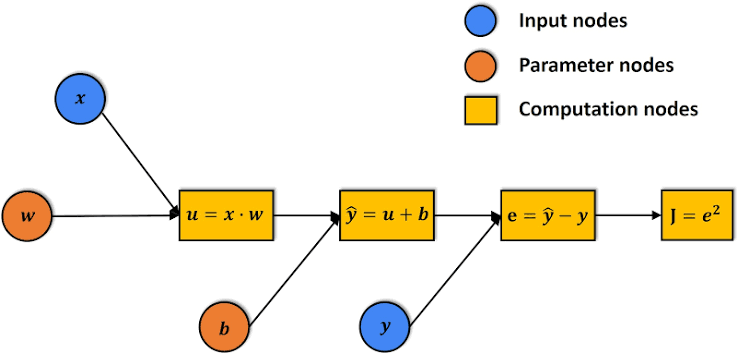

In [ ]:
torch.manual_seed(0)
N = 100
X = torch.rand(N, 1) * 4 - 2                  # x uniformly in [-2, 2]
TRUE_W, TRUE_B = 3.0, 2.0
Y = TRUE_W * X + TRUE_B + 0.5 * torch.randn(N, 1)   # add Gaussian noise

plt.figure(figsize=(5, 3.5))
plt.scatter(X, Y, s=12, alpha=0.7, label="noisy data")
plt.plot([-2, 2], [TRUE_W*-2 + TRUE_B, TRUE_W*2 + TRUE_B], "g--", label="true line y=3x+2")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Our toy regression dataset")
plt.show()

Now the manual training loop. Read it line by line — every line maps to one of the five steps above.

In [ ]:
w = torch.randn(1, requires_grad=True)   # random initial guess
b = torch.zeros(1, requires_grad=True)
lr = 0.1
losses = []

print(f"initial guess: w={w.item():.3f}, b={b.item():.3f}")
for epoch in range(100):
    y_hat = w * X + b                    # 1. forward
    loss = ((y_hat - Y) ** 2).mean()     # 2. loss (MSE)
    loss.backward()                      # 3. backward -> fills w.grad, b.grad

    with torch.no_grad():                # 4. update (must not be tracked!)
        w -= lr * w.grad
        b -= lr * b.grad

    w.grad.zero_()                       # 5. reset gradients
    b.grad.zero_()

    losses.append(loss.item())
    if epoch % 20 == 0 or epoch == 99:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f} | w {w.item():.3f} | b {b.item():.3f}")

print(f"\nlearned: w={w.item():.3f}, b={b.item():.3f}   (true: w=3, b=2)")

The learned values are close to — but not exactly — 3 and 2, because of the noise we added (with only 100 points, the *best possible* fit of this sample differs slightly from the true line). Let's visualise the loss curve and the fitted line.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(losses)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("MSE loss"); ax[0].set_title("Training loss")
ax[0].set_yscale("log")

xs = torch.linspace(-2, 2, 50).unsqueeze(1)
ax[1].scatter(X, Y, s=12, alpha=0.6, label="data")
ax[1].plot(xs, TRUE_W * xs + TRUE_B, "g--", label="true")
ax[1].plot(xs, (w * xs + b).detach(), "r", label="learned")   # detach before plotting
ax[1].legend(); ax[1].set_title("Fitted line")
plt.tight_layout(); plt.show()

---
# Part 4 — The same thing, the PyTorch way

In practice we don't manage parameters by hand. PyTorch gives us:

| Manual (Part 3) | PyTorch building block |
|---|---|
| `w`, `b` tensors with `requires_grad=True` | `nn.Linear(1, 1)` — an `nn.Module` that owns its parameters |
| `((y_hat - Y)**2).mean()` | `nn.MSELoss()` |
| `w -= lr * w.grad` inside `no_grad` | `optimizer.step()` |
| `w.grad.zero_()` | `optimizer.zero_grad()` |

The **canonical training step** you will write hundreds of times:

```python
optimizer.zero_grad()      # 1. clear old gradients
pred = model(x)            # 2. forward
loss = loss_fn(pred, y)    # 3. compute loss
loss.backward()            # 4. backward
optimizer.step()           # 5. update parameters
```

In [ ]:
import torch.nn as nn

torch.manual_seed(0)
model = nn.Linear(in_features=1, out_features=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(100):
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, Y)
    loss.backward()
    optimizer.step()

print(f"\nnn.Linear learned: w={model.weight.item():.3f}, b={model.bias.item():.3f}")
print(f"manual loop      : w={w.item():.3f}, b={b.item():.3f}")

Both approaches converge to the same solution. 🎉

Let's also try **Adam**, an adaptive optimizer that keeps a per-parameter running average of gradients (momentum) and of squared gradients (to scale the step size). It is often a robust default for deep networks. Note the different learning rate — each optimizer has its own sensible range.

In [ ]:
def fit_line(optimizer_cls, lr, epochs=100, **kwargs):
    torch.manual_seed(0)
    m = nn.Linear(1, 1)
    opt = optimizer_cls(m.parameters(), lr=lr, **kwargs)
    hist = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(m(X), Y)
        loss.backward()
        opt.step()
        hist.append(loss.item())
    return m, hist

runs = {
    "SGD lr=0.1":               fit_line(torch.optim.SGD, 0.1),
    "SGD lr=0.01":              fit_line(torch.optim.SGD, 0.01),
    "SGD lr=0.01 momentum=0.9": fit_line(torch.optim.SGD, 0.01, momentum=0.9),
    "Adam lr=0.1":              fit_line(torch.optim.Adam, 0.1),
}
plt.figure(figsize=(6, 3.5))
for name, (m, hist) in runs.items():
    plt.plot(hist, label=f"{name} (w={m.weight.item():.2f}, b={m.bias.item():.2f})")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(fontsize=8)
plt.title("Optimizer & learning-rate comparison"); plt.show()

**Discussion:** Why is `SGD lr=0.01` so slow? What does momentum change? Is Adam always better? (Hint: on this tiny convex problem, plain SGD with a good learning rate is excellent. Adam shines on large, badly-conditioned deep networks.)

---
# 🧪 Part 5 — Your turn (Lab 1, ~25 min)

Try each exercise yourself **before** revealing the solution below it.

### Exercise 1.1 — Shape prediction (5 min)
Without running code, write down the resulting shape (or "error") of each expression. Then check by running.

1. `torch.zeros(8, 1, 5) + torch.zeros(3, 1)`
2. `torch.zeros(4, 3) @ torch.zeros(3)`
3. `torch.zeros(2, 3, 4).sum(dim=1)`
4. `torch.zeros(2, 3, 4).permute(2, 0, 1)`
5. `torch.zeros(10, 3) + torch.zeros(10)`

In [ ]:
# TODO: write your predictions as comments, then evaluate each expression, e.g.
# print((torch.zeros(8, 1, 5) + torch.zeros(3, 1)).shape)

#### ✅ Solution (reveal after trying)

In [ ]:
exprs = {
    "zeros(8,1,5) + zeros(3,1)":   lambda: torch.zeros(8, 1, 5) + torch.zeros(3, 1),   # (8,3,5)
    "zeros(4,3) @ zeros(3)":       lambda: torch.zeros(4, 3) @ torch.zeros(3),         # (4,)  matrix-vector
    "zeros(2,3,4).sum(dim=1)":     lambda: torch.zeros(2, 3, 4).sum(dim=1),            # (2,4)
    "zeros(2,3,4).permute(2,0,1)": lambda: torch.zeros(2, 3, 4).permute(2, 0, 1),      # (4,2,3)
    "zeros(10,3) + zeros(10)":     lambda: torch.zeros(10, 3) + torch.zeros(10),       # error: 3 vs 10
}
for name, f in exprs.items():
    try:
        print(f"{name:30s} -> {tuple(f().shape)}")
    except RuntimeError as e:
        print(f"{name:30s} -> ERROR ({str(e)[:60]}...)")

### Exercise 1.2 — Verify autograd against calculus (5 min)
For $f(x) = x^3 + 2x$ and $g(x) = \sin(x)\cdot e^{x}$:
1. compute $f'(1.5)$ and $g'(0.5)$ with autograd,
2. compare to the analytic derivatives $f'(x) = 3x^2 + 2$ and $g'(x) = e^{x}(\sin x + \cos x)$.

*Hint:* create a fresh tensor with `requires_grad=True` for each function, call `.backward()`, read `.grad`.

In [ ]:
# TODO: your code here

#### ✅ Solution (reveal after trying)

In [ ]:
import math

x = torch.tensor(1.5, requires_grad=True)
f = x**3 + 2*x
f.backward()
print(f"f'(1.5): autograd={x.grad.item():.5f}  analytic={3*1.5**2 + 2:.5f}")

x = torch.tensor(0.5, requires_grad=True)
g = torch.sin(x) * torch.exp(x)
g.backward()
print(f"g'(0.5): autograd={x.grad.item():.5f}  analytic={math.exp(0.5)*(math.sin(0.5)+math.cos(0.5)):.5f}")

### Exercise 1.3 — Break it on purpose: learning rate too large (5 min)
Re-run the **manual** gradient descent from Part 3 with `lr = 0.5` and `lr = 1.0`. Print or plot the loss.
What happens and why?

*Hint:* copy the loop into a function `manual_gd(lr, epochs)` that returns the list of losses.

In [ ]:
# TODO: your code here

#### ✅ Solution (reveal after trying)

In [ ]:
def manual_gd(lr, epochs=30):
    torch.manual_seed(1)
    w = torch.randn(1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    hist = []
    for _ in range(epochs):
        loss = ((w * X + b - Y) ** 2).mean()
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
        w.grad.zero_(); b.grad.zero_()
        hist.append(loss.item())
    return hist

plt.figure(figsize=(6, 3.5))
for lr in [0.1, 0.5, 1.0]:
    plt.plot(manual_gd(lr), label=f"lr={lr}")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE (log)"); plt.legend()
plt.title("Too large a learning rate makes GD diverge"); plt.show()
# With lr=1.0 each step overshoots the minimum by more than it corrects -> the loss explodes.
# (For this data the curvature along w is ~2*E[x^2] ≈ 2.7, so any lr > 2/2.7 ≈ 0.75 diverges.)

### Exercise 1.4 — Fit a parabola from scratch (10 min)
Generate data from $y = 0.5x^2 - x + 1$ plus noise (std 0.3) for $x \in [-2, 2]$ and recover the three coefficients $a, b, c$ of $\hat y = a x^2 + b x + c$ with **manual** gradient descent (no `nn`, no `optim`).

*Hints:* three tensors with `requires_grad=True`; use `lr = 0.05` and ~1000 epochs; remember `no_grad` and `zero_()`.

**Bonus:** do it again with `nn.Linear(2, 1)` on the features `[x², x]` and `torch.optim.Adam`.

In [ ]:
# TODO: your code here

#### ✅ Solution (reveal after trying)

In [ ]:
torch.manual_seed(0)
Xq = torch.rand(200, 1) * 4 - 2
Yq = 0.5 * Xq**2 - 1.0 * Xq + 1.0 + 0.3 * torch.randn(200, 1)

a = torch.zeros(1, requires_grad=True)
b_ = torch.zeros(1, requires_grad=True)
c = torch.zeros(1, requires_grad=True)
lr = 0.05
for epoch in range(1000):
    loss = ((a * Xq**2 + b_ * Xq + c - Yq) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        for p in (a, b_, c):
            p -= lr * p.grad
            p.grad.zero_()
print(f"manual GD : a={a.item():.3f}, b={b_.item():.3f}, c={c.item():.3f}  (true 0.5, -1, 1) | loss={loss.item():.4f}")

# Bonus: nn.Linear on engineered features [x^2, x]
feats = torch.cat([Xq**2, Xq], dim=1)            # shape (200, 2)
lin = nn.Linear(2, 1)
opt = torch.optim.Adam(lin.parameters(), lr=0.05)
for epoch in range(1000):
    opt.zero_grad()
    loss = loss_fn(lin(feats), Yq)
    loss.backward()
    opt.step()
wa, wb = lin.weight.detach().flatten().tolist()
print(f"nn+Adam   : a={wa:.3f}, b={wb:.3f}, c={lin.bias.item():.3f} | loss={loss.item():.4f}")

---
## ✅ Key takeaways

* A tensor = data + **shape** + **dtype** + **device**. Print these first when debugging.
* **Broadcasting** is powerful but can hide bugs (`(N,1)` vs `(N,)`).
* `requires_grad=True` → PyTorch builds a **computational graph**; `.backward()` fills `.grad` via the chain rule.
* Gradients **accumulate** → always `zero_grad()`.
* Use `torch.no_grad()` for evaluation and manual updates; `.detach()` to get plain data out.
* The training step is always: **zero_grad → forward → loss → backward → step**.

➡️ Next: **Notebook 02** — the same loop, but with a convolutional neural network on real images (FashionMNIST).